<a href="https://colab.research.google.com/github/irakafc/Portfolio/blob/Projects/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:

# información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


El dataset contiene 40,000 registros y 9 columnas.

No se observan valores ausentes en ninguna de las variables, por lo que no será necesario realizar imputaciones o eliminación de registros.

La mayoría de las columnas tienen tipos de datos adecuados:
- `user_id`, `landing`, `region`, `dispositivo`, `traffic_source` y `user_type` son variables categóricas.
- `converted` es una variable binaria representada como entero (`int64`).
- `gasto` es una variable numérica continua (`float64`).

La columna `date` actualmente es de tipo `object` y debería convertirse a tipo fecha (`datetime`) para facilitar análisis temporales si fueran necesarios posteriormente.

En general, el dataset presenta buena calidad inicial y puede continuar con el proceso de exploración y análisis estadístico.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# Verificar usuarios únicos
print(df["user_id"].nunique())

# Comparar con total de registros
print(len(df))

40000
40000


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:

# Resumen estadístico de usuarios que se convirtieron
print(df[df["converted"] == 1]["gasto"].describe())

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:


# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())



Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64



La variable `landing` contiene únicamente las categorías esperadas del experimento: `A` y `B`.

No se observan categorías mal escritas, duplicadas o inesperadas, por lo que no es necesario realizar correcciones adicionales.

La distribución entre ambas versiones permitirá comparar correctamente el desempeño del experimento A/B.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:


# Gasto por versión
gasto_A = df[
    (df["landing"] == "A") &
    (df["converted"] == 1)
]["gasto"]

gasto_B = df[
    (df["landing"] == "B") &
    (df["converted"] == 1)
]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

In [ ]:

# Mostrar promedio de gasto por grupo
print("Promedio gasto versión A:", gasto_A.mean())
print("Promedio gasto versión B:", gasto_B.mean())


Promedio gasto versión A: 61.0865724522293
Promedio gasto versión B: 68.74536005009392


### Prueba t de Student para muestras independientes

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Sí existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


### 📝 Conclusión e interpretación
**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en el gasto promedio entre la página A y la página B para los usuarios que realizaron una conversión.

La versión B genera un gasto promedio mayor por usuario convertido en comparación con la versión A, lo que sugiere que la página B tiene un mejor desempeño económico y podría representar una mejor alternativa para maximizar ingresos.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z para diferencia de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Sí existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

In [ ]:

# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Tabla de contingencia normalizada en porcentaje
tabla_conversion_pct = pd.crosstab(
    df["landing"],
    df["converted"],
    normalize='index'
) * 100

print(tabla_conversion_pct)

converted          0          1
landing                        
A          87.428686  12.571314
B          84.044360  15.955640


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(
    conversiones,
    totales
)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Existe evidencia estadísticamente significativa de que la tasa de conversión es diferente entre la página A y la página B.

Esto indica que una de las versiones logra convertir a más usuarios que la otra. Al comparar las tasas de conversión de cada grupo, se podrá identificar cuál versión de la landing page tiene un mejor desempeño para generar conversiones y potencialmente aumentar los ingresos del negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`).
- **Hipótesis alternativa (H₁):** Sí existe una asociación estadísticamente significativa entre la fuente de tráfico (`traffic_source`) y la conversión (`converted`).

In [ ]:
# Tabla de contingencia
tabla_trafico = pd.crosstab(
    df["traffic_source"],
    df["converted"]
)

print("Tabla de contingencia:\n")
print(tabla_trafico)


Tabla de contingencia:

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)


print("\nEstadístico chi-cuadrado:", chi2_stat)
print("Valor p:", p_value)


Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914


**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Existe evidencia estadísticamente significativa de una asociación entre la fuente de tráfico y la conversión de usuarios.

Esto indica que el canal por el que llega el usuario está relacionado con la probabilidad de conversión. Algunos canales generan proporcionalmente más conversiones que otros, por lo que la empresa podría optimizar su inversión enfocándose en las fuentes de tráfico con mejor desempeño.

Además, se observa que `Organic` y `Ads` concentran el mayor volumen de conversiones, aunque es importante analizar las tasas de conversión relativas para identificar qué canal es realmente más eficiente.

Sin embargo, esta prueba únicamente identifica asociación entre variables y no demuestra causalidad. Es decir, no se puede concluir que la fuente de tráfico por sí sola provoque directamente la conversión.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre el tipo de usuario (`user_type`) y la conversión (`converted`).
- **Hipótesis alternativa (H₁):** Sí existe una asociación estadísticamente significativa entre el tipo de usuario (`user_type`) y la conversión (`converted`).

In [ ]:
# Tabla de contingencia
tabla_usuario = pd.crosstab(
    df["user_type"],
    df["converted"]
)

print("Tabla de contingencia:\n")
print(tabla_usuario)

Tabla de contingencia:

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

print("\nEstadístico chi-cuadrado:", chi2_stat)
print("Valor p:", p_value)


Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula.

**Interpretación de negocio:**  
No existe evidencia estadísticamente significativa de una asociación entre el tipo de usuario (`Nuevo` o `Recurrente`) y la conversión (`converted`) en el contexto analizado.

Esto sugiere que, dentro de este experimento, los usuarios recurrentes no presentan una probabilidad de conversión significativamente distinta a la de los usuarios nuevos.

Por lo tanto, no se identifican diferencias relevantes en conversión que justifiquen, por ahora, una estrategia diferenciada únicamente basada en el tipo de usuario.

Además, esta prueba únicamente evalúa asociación entre variables y no demuestra causalidad.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

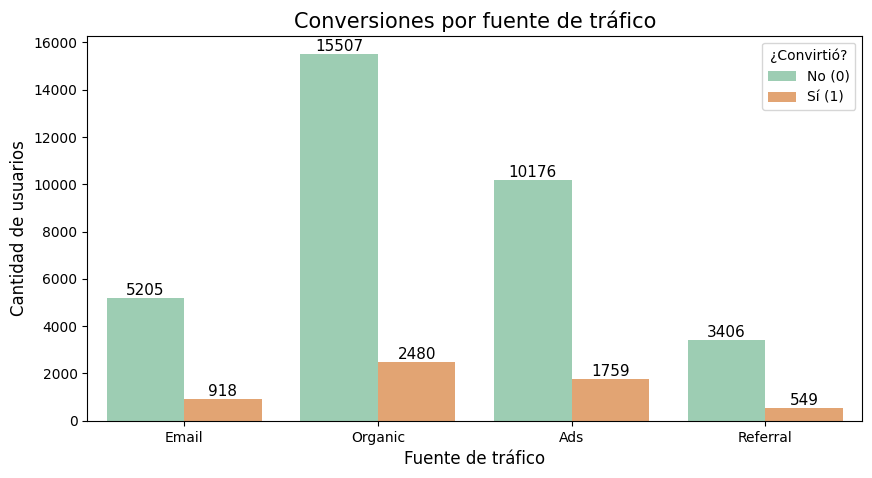

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x='traffic_source',
    hue='converted',
    palette=["#95D5B2", "#F4A261"]
)

# Agregar valores
for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=height,
        s=int(height),
        ha='center',
        va='bottom',
        fontsize=11
    )

# Añadir detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)

plt.legend(
    title='¿Convirtió?',
    labels=['No (0)', 'Sí (1)']
)

plt.show()

### 📊 Gráfico 1: Conversiones por fuente de tráfico

Este gráfico muestra la distribución absoluta de usuarios que convierten (1) y no convierten (0) según la fuente de tráfico.

Se observa que **Organic y Ads concentran el mayor volumen de usuarios**, lo cual es esperado por ser los canales con mayor tráfico.

Sin embargo, aunque el volumen de conversiones es mayor en estos canales, esto se debe principalmente al tamaño total de usuarios y no necesariamente a una mejor eficiencia.


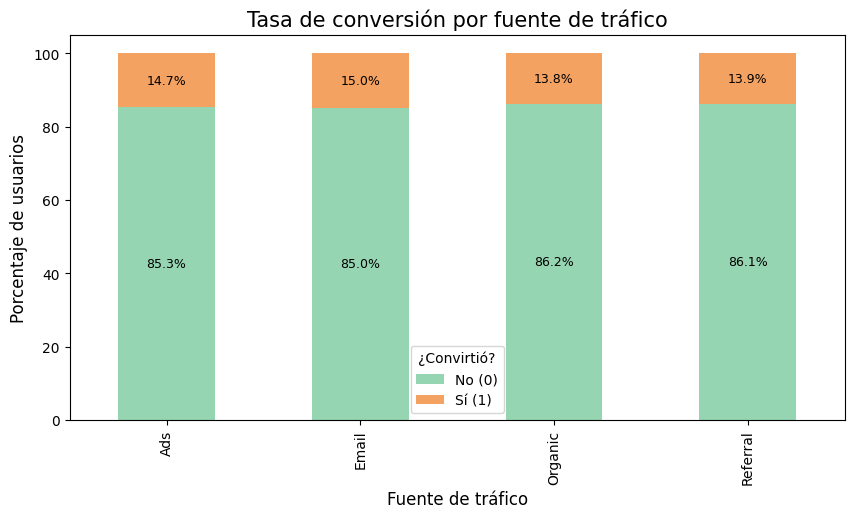

In [ ]:
# Tabla normalizada en porcentaje
tabla_trafico_pct = pd.crosstab(
    df["traffic_source"],
    df["converted"],
    normalize='index'
) * 100

# Gráfico de barras apiladas
ax = tabla_trafico_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=["#95D5B2", "#F4A261"]
)

# Agregar porcentajes manualmente (compatible)
for i, bars in enumerate(ax.containers):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=9
            )

# Detalles del gráfico
plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Porcentaje de usuarios', fontsize=12)

plt.legend(
    title='¿Convirtió?',
    labels=['No (0)', 'Sí (1)']
)

plt.show()


### 📊 Gráfico 2: Tasa de conversión por fuente de tráfico

Este gráfico muestra la proporción de conversión dentro de cada fuente de tráfico, lo que permite comparar la **eficiencia real de cada canal**.

Se observa que las tasas de conversión son bastante similares entre canales, con ligeras variaciones:
- Email presenta una tasa ligeramente mayor (~15%)
- Organic y Referral tienen tasas ligeramente menores (~13.8% - 13.9%)



### Relación entre el tipo de usuario y la conversión

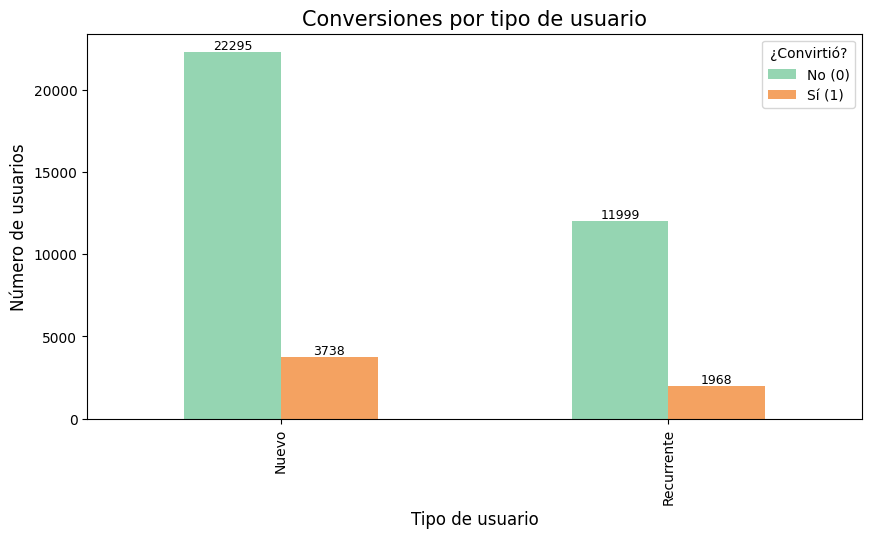

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabla absoluta de conversiones por tipo de usuario
tabla_usuario = pd.crosstab(
    df["user_type"],   # columna de tipo de usuario
    df["converted"]    # columna de conversión
)

# Gráfico 1: Conversiones absolutas por tipo de usuario (barras agrupadas)
ax = tabla_usuario.plot(
    kind='bar',
    figsize=(10, 5),
    color=["#95D5B2", "#F4A261"]
)

# Agregar etiquetas manuales en cada barra
for bars in ax.containers:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height)}",
                ha='center',
                va='bottom',
                fontsize=9
            )

# Detalles del gráfico
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)

plt.legend(
    title='¿Convirtió?',
    labels=['No (0)', 'Sí (1)']
)

plt.show()


### 📊 Gráfico 1: Conversiones por tipo de usuario
Este gráfico muestra la distribución absoluta de usuarios que convierten (1) y no convierten (0) según el tipo de usuario.

Los usuarios nuevos representan el mayor volumen total, con más de 22,000 que no convierten y alrededor de 3,700 que sí convierten.

Los usuarios recurrentes son menos en cantidad (cerca de 12,000 no convierten y casi 2,000 sí convierten), pero siguen aportando conversiones relevantes.


La conclusión es que el volumen de conversiones de los nuevos usuarios es mayor en números absolutos, pero esto se debe principalmente a que son más numerosos



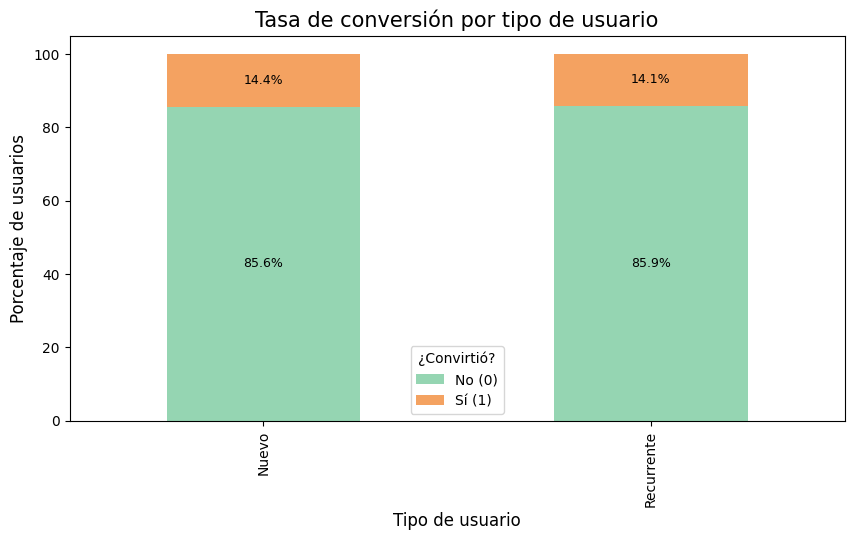

In [ ]:
# Gráfico 2: Tasa de conversión por tipo de usuario
ax2 = tabla_usuario_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=["#95D5B2", "#F4A261"]
)

# Agregar porcentajes manualmente
for i, bars in enumerate(ax2.containers):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=9
            )

# Detalles del gráfico
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Porcentaje de usuarios', fontsize=12)

plt.legend(
    title='¿Convirtió?',
    labels=['No (0)', 'Sí (1)']
)

plt.show()

### 📊 Gráfico 2: Tasa de conversión por tipo de usuario
Este gráfico muestra la proporción de conversión dentro de cada tipo de usuario, lo que permite comparar la eficiencia real de cada segmento.

Se observa que las tasas de conversión son muy similares entre ambos grupos:

Los usuarios nuevos presentan una tasa de conversión de aproximadamente 14.4%.

Los usuarios recurrentes muestran una tasa cercana al 14.1%.

La conclusión es que, aunque los usuarios nuevos aportan más volumen total, la eficiencia relativa de conversión es prácticamente igual en ambos segmentos.
Esto sugiere que no hay diferencias significativas en la tasa de conversión entre nuevos y recurrentes, por lo que la estrategia debería enfocarse en maximizar el volumen de captación y retención, más que en esperar un rendimiento diferencial por tipo de usuario.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

# 🌟 Insight Ejecutivo basado en el Experimento A/B

---

## 🔍 **Comparación de Página (A vs B)**

### 💰 **Gasto promedio por usuario que convirtió**

> **Observación 1:**  
La versión **A** presenta un gasto promedio de **61.1** por usuario convertido.

> **Observación 2:**  
La versión **B** presenta un gasto promedio de **68.7**, superior al de la versión A.

### 📌 **Interpretación**
La diferencia es **estadísticamente significativa** (*prueba t de Student*), lo que indica que la versión **B** genera mayor valor económico por usuario convertido y representa una mejor alternativa para maximizar ingresos.

---

### 📈 **Tasa de conversión**

> **Observación 1:**  
La versión **A** convierte a **2,512 de 19,982 usuarios**, equivalente a una tasa de conversión de **12.57%**.

> **Observación 2:**  
La versión **B** convierte a **3,194 de 20,018 usuarios**, alcanzando una tasa de conversión de **15.96%**.

### 📌 **Interpretación**
La diferencia es **estadísticamente significativa** (*prueba Z de proporciones*), demostrando que la versión **B** convierte más usuarios y tiene un mejor desempeño en captación.

---

# 📊 **Segmentación por Fuente de Tráfico**

## 🔹 Observación 1

| Fuente de tráfico | No convierten | Convierten | Tasa de conversión |
|---|---:|---:|---:|
| Organic | 15,507 | 2,480 | 13.8% |
| Ads | 10,176 | 1,759 | 14.7% |
| Email | 5,205 | 918 | 15.0% |
| Referral | 3,406 | 549 | 13.9% |

---

## 🔹 Observación 2

- **Organic** y **Ads** concentran el mayor volumen absoluto de conversiones (**2,480** y **1,759** respectivamente).
- **Email**, aunque con menor volumen, presenta la **tasa de conversión más alta (~15%)**, convirtiéndose en el canal más eficiente en términos relativos.
- **Referral** aporta menos usuarios, pero mantiene una tasa similar a Organic (~13.9%).

---

### 📌 **Interpretación**

La prueba **Chi-cuadrada** confirma que existe una **asociación estadísticamente significativa** entre la fuente de tráfico y la conversión.

Esto significa que el canal por el que llega el usuario **sí influye** en la probabilidad de conversión.

### ✅ Conclusiones clave

- Para **volumen**, conviene mantener inversión en **Organic** y **Ads**, ya que concentran la mayor cantidad de usuarios convertidos.
- Para **eficiencia relativa**, se recomienda reforzar **Email marketing**, dado que convierte proporcionalmente más usuarios.
- **Referral** puede mantenerse como canal secundario debido a su menor aporte en volumen.

> ⚠️ **Importante:**  
La prueba únicamente identifica asociación entre variables y **no demuestra causalidad**. No se puede concluir que la fuente de tráfico por sí sola provoque directamente la conversión.

---

# 📊 **Segmentación por Tipo de Usuario**

## 🔹 Observación 1

| Tipo de usuario | No convierten | Convierten | Tasa de conversión |
|---|---:|---:|---:|
| Usuarios nuevos | 22,295 | 3,738 | 14.4% |
| Usuarios recurrentes | 11,999 | 1,968 | 14.1% |

---

### 📌 **Interpretación**

La prueba **Chi-cuadrada** confirma que **no existe asociación estadísticamente significativa** entre el tipo de usuario y la conversión.

Esto implica que:

- Los **usuarios nuevos** aportan mayor volumen absoluto de conversiones, principalmente por su mayor tamaño poblacional.
- Los **usuarios recurrentes** muestran una tasa de conversión prácticamente igual a la de los nuevos (**diferencia de apenas 0.3 puntos porcentuales**).
- No se justifica una estrategia diferenciada únicamente por tipo de usuario, ya que ambos segmentos convierten en proporciones similares.

---

## 📉 **Conclusión Visual**

Las visualizaciones utilizadas respaldan los resultados estadísticos obtenidos en las pruebas anteriores.

---

# 💡 **Recomendaciones de Negocio**

## ✅ Adoptar la versión B de la landing page

La evidencia estadística demuestra que la versión **B** supera claramente a la versión **A** tanto en:

- **Tasa de conversión:**  
  **16.0% vs 12.6%**

- **Gasto promedio por usuario convertido:**  
  **68.7 vs 61.1**

### 🚀 Impacto estimado

- **27% más conversiones relativas**
- **12.5% más ingreso por usuario**

➡️ Esto consolida a la versión **B** como la mejor alternativa para maximizar ingresos.

---

## 🎯 Optimizar inversión en canales de tráfico

### 📧 Email Marketing
Debe reforzarse, ya que presenta la tasa de conversión más alta (~15%), siendo el canal más eficiente en términos relativos.

### 📢 Ads y Organic
Deben mantenerse como canales principales para volumen, debido a que concentran la mayor cantidad absoluta de conversiones.

### 🔗 Referral
Puede conservarse como canal secundario, ya que aporta menor volumen y tasas similares a Organic.

---

## 👥 No segmentar agresivamente por tipo de usuario

Los resultados muestran que:

- Usuarios nuevos → **14.4%**
- Usuarios recurrentes → **14.1%**

Las tasas son prácticamente iguales y sin diferencias estadísticamente significativas.

➡️ Esto indica que segmentar campañas únicamente por tipo de usuario no aporta ventajas claras en este experimento.

---

# 🚀 Estrategia Integral Recomendada

## 📌 Combinación óptima

- ✅ Implementar la **Versión B** como landing principal.
- ✅ Reforzar **Email Marketing** para maximizar eficiencia.
- ✅ Mantener **Ads** y **Organic** como motores de volumen.
- ✅ Explorar estrategias de fidelización a futuro, aunque no son prioritarias en el contexto actual.

---

# 📈 Pasos a Seguir en el Análisis de Datos

---

# 🔍 **1. Profundizar en Segmentaciones Adicionales**

## 📌 Objetivo
Identificar patrones ocultos que puedan explicar diferencias en comportamiento y conversión entre distintos grupos de usuarios.

### ✅ Acciones propuestas

- Analizar resultados por:
  - 🌎 **Región geográfica**
  - 📱 **Tipo de dispositivo** (mobile, desktop, tablet)

- Evaluar si existen diferencias estadísticamente significativas en:
  - 📈 Tasa de conversión
  - 💰 Gasto promedio

### 🎯 Beneficio esperado
Detectar segmentos con mayor rentabilidad o desempeño para optimizar campañas y personalización.

---

# 🔄 **2. Explorar Interacciones entre Variables**

## 📌 Objetivo
Comprender cómo la combinación de variables influye en la probabilidad de conversión.

### ✅ Acciones propuestas

- Revisar combinaciones como:
  - Fuente de tráfico + tipo de usuario
  - Dispositivo + versión de página
  - Región + canal de adquisición

- Aplicar modelos de:
  - 📊 **Regresión logística**
  - 📉 Modelos multivariados

### 🎯 Beneficio esperado
Cuantificar el impacto conjunto de múltiples factores y detectar efectos que no son visibles de forma aislada.

---

# 🧪 **3. Validar la Robustez del Experimento**

## 📌 Objetivo
Garantizar que los resultados obtenidos sean confiables y generalizables.

### ✅ Acciones propuestas

- Confirmar que la distribución de usuarios entre:
  - Versión **A**
  - Versión **B**

permanece balanceada en todas las categorías analizadas.

- Realizar:
  - 🔬 Pruebas de sensibilidad
  - 📊 Validaciones por subgrupos

### 🎯 Beneficio esperado
Asegurar que los resultados no dependan de un segmento específico o de sesgos en la muestra.

---

# 💰 **4. Proyectar Impacto Económico**

## 📌 Objetivo
Traducir los hallazgos estadísticos en métricas de negocio accionables.

### ✅ Acciones propuestas

- Estimar:
  - 💵 Ingresos adicionales esperados al implementar la versión **B**
  - 📈 Incremento potencial en ROI

- Simular escenarios de inversión:
  - 📧 Mayor presupuesto en **Email Marketing**
  - 📢 Incremento en **Ads**
  - 🌱 Optimización de tráfico **Organic**

### 🎯 Beneficio esperado
Priorizar estrategias con mayor retorno económico esperado.

---